In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

# ==========================
# 1. 图加载
# ==========================

def load_graph(node_csv, edge_csv, device="cpu"):
    nodes = pd.read_csv(node_csv)
    num_nodes = len(nodes)

    edges = pd.read_csv(edge_csv)
    src = torch.tensor(edges["src"].values, dtype=torch.int64)
    dst = torch.tensor(edges["dst"].values, dtype=torch.int64)

    g = dgl.graph((src, dst), num_nodes=num_nodes)
    g = dgl.add_edges(g, dst, src)
    g = dgl.add_self_loop(g)


    return g.to(device), edges, num_nodes


# ==========================
# 2. 构造训练样本
# ==========================

def sample_non_edges(num_nodes, edges, num_samples):
    exist = set(zip(edges["src"], edges["dst"]))
    print(len(exist))
    samples = []

    while len(samples) < num_samples:
        s = np.random.randint(0, num_nodes)
        d = np.random.randint(0, num_nodes)
        if s != d and (s, d) not in exist:
            samples.append((s, d))
    return samples


def build_samples(g, edges, num_nodes):
    pos = edges[edges["label"] == 1]
    neg = edges[edges["label"] == 2]

    src, dst, label = [], [], []

    for _, r in pos.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(1)

    for _, r in neg.iterrows():
        src.append(r.src)
        dst.append(r.dst)
        label.append(2)

    # 采样无边
    non_edges = sample_non_edges(num_nodes, edges, len(pos))
    for s, d in non_edges:
        src.append(s)
        dst.append(d)
        label.append(0)

    return torch.tensor(src), torch.tensor(dst), torch.tensor(label)


# ==========================
# Dataset
# ==========================

class EdgeDataset(Dataset):
    def __init__(self, src, dst, label):
        self.src = src
        self.dst = dst
        self.label = label

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        return self.src[idx], self.dst[idx], self.label[idx]


# ==========================
# RGCN + 三分类 Decoder
# ==========================

from dgl.nn import GraphConv

class RGCNEncoder(nn.Module):
    def __init__(self, in_feats=16, h_feats=32, out_feats=32):
        super().__init__()
        self.layer1 = GraphConv(in_feats, h_feats)
        self.layer2 = GraphConv(h_feats, out_feats)

    def forward(self, g, feat):
        h = torch.relu(self.layer1(g, feat))
        h = self.layer2(g, h)
        return h

import torch.nn.functional as F
from dgl.nn.pytorch import GATConv


class GATEncoder(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout

        # 第一层：in_dim → hidden_dim
        self.layer1 = GATConv(
            in_dim,
            hidden_dim,
            num_heads=num_heads,
            feat_drop=0,
            attn_drop=0
        )

        # 第二层：hidden_dim → out_dim
        # 注意：上一层会输出 hidden_dim * num_heads
        self.layer2 = GATConv(
            hidden_dim,
            out_dim,
            num_heads=1,
            feat_drop=dropout,
            attn_drop=dropout
        )

    def forward(self, g, feat):
        # Layer1
        h = self.layer1(g, feat)       # shape: [N, num_heads, hidden_dim]
        h = h.mean(dim=1)              # 多头求平均 → [N, hidden_dim]
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer2
        h = self.layer2(g, h)          # shape: [N, 1, out_dim]
        h = h.squeeze(1)               # → [N, out_dim]
        return h

from dgl.nn.pytorch import HGTConv
class HGTEncoder(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()

        # 在同构图中，节点类型=1，边类型=1
        self.num_ntypes = 1
        self.num_etypes = 1
        self.dropout = dropout

        self.layer1 = HGTConv(
            in_dim, hidden_dim, num_heads,
            self.num_ntypes, self.num_etypes,
            dropout=dropout, use_norm=True
        )

        self.layer2 = HGTConv(
            hidden_dim * num_heads, out_dim, 1,
            self.num_ntypes, self.num_etypes,
            dropout=dropout, use_norm=True
        )

    def forward(self, g, feat):
        N = g.num_nodes()

        # 同构图 → 所有节点的 type_id=0
        ntype = torch.zeros(N, dtype=torch.long, device=feat.device)

        # 同构图 → 所有边的 type_id=0
        etype = torch.zeros(g.num_edges(), dtype=torch.long, device=feat.device)

        # Layer1
        h = self.layer1(g, feat, ntype, etype)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer2
        h = self.layer2(g, h, ntype, etype)   # shape [N,1,out_dim]
        h = h.squeeze(1)                      # → [N, out_dim]
        return h



class EdgeClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, emb, src, dst):
        h = torch.cat([emb[src], emb[dst]], dim=1)
        return self.mlp(h)


class RGCNModel(nn.Module):
    def __init__(self, in_dim=16):
        super().__init__()
        self.encoder = RGCNEncoder(in_dim, 32, 32)
        self.decoder = EdgeClassifier(32, 64, 3)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)

class GATModel(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.encoder = GATEncoder(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        self.decoder = EdgeClassifier(out_dim)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)


class HGTModel(nn.Module):
    def __init__(self, in_dim=16, hidden_dim=32, out_dim=32, num_heads=4, dropout=0.2):
        super().__init__()
        self.encoder = HGTEncoder(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            out_dim=out_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        self.decoder = EdgeClassifier(out_dim)

    def forward(self, g, feat, src, dst):
        emb = self.encoder(g, feat)
        return self.decoder(emb, src, dst)

# ==========================
# Train & Eval
# ==========================
def multi_class_pr_auc(labels, probs, num_classes=3):
    prcs = []
    for c in range(num_classes):
        y_true = (labels == c).astype(int)
        y_score = probs[:, c]

        if y_true.sum() == 0:   # 跳过没有真实样本的类别
            continue

        prc = average_precision_score(y_true, y_score)
        prcs.append(prc)

    return np.mean(prcs) if len(prcs) > 0 else 0.0

def evaluate(model, loader, g, feat, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    criterion = nn.CrossEntropyLoss()
    total_loss = 0

    with torch.no_grad():
        for s, d, y in loader:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    labels = np.array(all_labels)
    preds = np.array(all_preds)
    probs = np.array(all_probs)

    acc = accuracy_score(labels, preds)
    pre = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro")

    # AUC（多分类用 OvR）
    auc = roc_auc_score(labels, probs, multi_class="ovr")
    prc = multi_class_pr_auc(labels, probs, num_classes=3)

    return total_loss, acc, pre, rec, f1, auc, prc


# ==========================
# 主函数
# ==========================

def train_model(node_csv, edge_csv):
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    g, edges, num_nodes = load_graph(node_csv, edge_csv, device)

    # 节点特征
    feat = torch.randn((num_nodes, 16), device=device)

    # 构造三分类样本
    src, dst, label = build_samples(g, edges, num_nodes)

    # Train / Val 划分
    s_train, s_val, d_train, d_val, y_train, y_val = train_test_split(
        src, dst, label, test_size=0.2, shuffle=True
    )

    train_loader = DataLoader(EdgeDataset(s_train, d_train, y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(EdgeDataset(s_val, d_val, y_val), batch_size=256, shuffle=False)

    # model = RGCNModel(in_dim=16).to(device)
    # model = GATModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)
    model = HGTModel(in_dim=16, hidden_dim=32, out_dim=32, num_heads=4).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # ==========================
    # Training Loop
    # ==========================

    from tqdm import tqdm
    prc_list = []
    auc_list = []
    f1_list = []
    train_loss_list = []
    val_loss_list = []
    for epoch in range(20):
        model.train()
        total_loss = 0

        # tqdm 外层：epoch 进度
        epoch_iter = tqdm(train_loader, desc=f"Epoch {epoch:02d}", ncols=100)

        for s, d, y in epoch_iter:
            s, d, y = s.to(device), d.to(device), y.to(device)

            logits = model(g, feat, s, d)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # 在进度条实时显示当前 batch loss
            epoch_iter.set_postfix(loss=f"{loss.item():.4f}")

        # -------------------
        # 验证
        # -------------------
        val_loss, acc, pre, rec, f1, auc, prc = evaluate(model, val_loader, g, feat, device)
        prc_list.append(prc)
        auc_list.append(auc)
        f1_list.append(f1)
        train_loss_list.append(total_loss)
        val_loss_list.append(val_loss)

        print(
            f"[Epoch {epoch:02d}] "
            f"Train Loss={total_loss:.4f} | "
            f"Val Loss={val_loss:.4f} | "
            f"Acc={acc:.4f} | Pre={pre:.4f} | Rec={rec:.4f} | "
            f"F1={f1:.4f} | AUC={auc:.4f} | PRC={prc:.4f}"
        )

    print("训练完成！")
    results = {
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "prc": prc_list,
        "auc": auc_list,
        "f1": f1_list
    }
    return model,results



In [2]:
print("正在处理：", "data_signed/edges_labeled_pos10x.csv",)
model,dict_imb10 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos10x.csv")
print(dict_imb10)
print("=============================================================================")

正在处理： data_signed/edges_labeled_pos10x.csv


Epoch 00: 100%|████████████████████████████████████| 1801/1801 [03:11<00:00,  9.38it/s, loss=0.5122]


[Epoch 00] Train Loss=971.8904 | Val Loss=51.0365 | Acc=0.8088 | Pre=0.8343 | Rec=0.6924 | F1=0.7353 | AUC=0.9139 | PRC=0.8146


Epoch 01: 100%|████████████████████████████████████| 1801/1801 [03:11<00:00,  9.40it/s, loss=0.4232]


[Epoch 01] Train Loss=823.6415 | Val Loss=46.5630 | Acc=0.8294 | Pre=0.8525 | Rec=0.7452 | F1=0.7816 | AUC=0.9298 | PRC=0.8539


...

[Epoch 17] Train Loss=487.1691 | Val Loss=28.6757 | Acc=0.9028 | Pre=0.8761 | Rec=0.8880 | F1=0.8809 | AUC=0.9728 | PRC=0.9374


Epoch 18: 100%|████████████████████████████████████| 1801/1801 [03:11<00:00,  9.42it/s, loss=0.2533]


[Epoch 18] Train Loss=479.8467 | Val Loss=29.3929 | Acc=0.9011 | Pre=0.8649 | Rec=0.8907 | F1=0.8763 | AUC=0.9727 | PRC=0.9345


Epoch 19: 100%|████████████████████████████████████| 1801/1801 [03:10<00:00,  9.43it/s, loss=0.2239]


[Epoch 19] Train Loss=471.0751 | Val Loss=27.6562 | Acc=0.9058 | Pre=0.8901 | Rec=0.8799 | F1=0.8841 | AUC=0.9746 | PRC=0.9422
训练完成！
{'train_loss': [971.8904194235802, 823.641493216157, 757.657744243741, 721.4903952777386, 691.0705564320087, 663.5359952300787, 632.9834469109774, 604.7709380090237, 588.8968462347984, 569.5884559452534, 552.7571794390678, 541.1073409020901, 529.2048004642129, 522.3870730772614, 511.3249693438411, 501.80997136607766, 492.63165421783924, 487.169059894979, 479.8466742709279, 471.0751117095351], 'val_loss': [51.03645148873329, 46.56302082538605, 42.504193753004074, 40.415897607803345, 39.66426035761833, 37.79953229427338, 36.09214322268963, 35.48427492380142, 33.16470558941364, 32.83046281337738, 31.40341804921627, 31.368995651602745, 32.0844262689352, 31.10556434094906, 30.025876358151436, 29.64126844704151, 29.20262661576271, 28.675654262304306, 29.392862305045128, 27.656196519732475], 'prc': [0.8145991337317652, 0.853855037697452, 0.8714063826237322, 0.88

In [3]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos20x.csv",)
    model,dict_imb20 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos20x.csv")
    print(dict_imb20)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos20x.csv


Epoch 00: 100%|████████████████████████████████████| 3517/3517 [10:20<00:00,  5.67it/s, loss=0.4401]


[Epoch 00] Train Loss=1792.7881 | Val Loss=98.8791 | Acc=0.8069 | Pre=0.8402 | Rec=0.6449 | F1=0.6903 | AUC=0.8958 | PRC=0.7648


Epoch 01: 100%|████████████████████████████████████| 3517/3517 [10:17<00:00,  5.70it/s, loss=0.2799]


[Epoch 01] Train Loss=1584.2464 | Val Loss=92.4287 | Acc=0.8229 | Pre=0.8188 | Rec=0.6892 | F1=0.7299 | AUC=0.9118 | PRC=0.7877


...

[Epoch 17] Train Loss=1082.9255 | Val Loss=65.4416 | Acc=0.8819 | Pre=0.8669 | Rec=0.8069 | F1=0.8314 | AUC=0.9610 | PRC=0.8933


Epoch 18: 100%|████████████████████████████████████| 3517/3517 [10:19<00:00,  5.67it/s, loss=0.2093]


[Epoch 18] Train Loss=1078.8854 | Val Loss=64.0949 | Acc=0.8814 | Pre=0.8596 | Rec=0.8015 | F1=0.8261 | AUC=0.9617 | PRC=0.8945


Epoch 19: 100%|████████████████████████████████████| 3517/3517 [10:19<00:00,  5.68it/s, loss=0.6333]


[Epoch 19] Train Loss=1072.8258 | Val Loss=63.7488 | Acc=0.8823 | Pre=0.8517 | Rec=0.8279 | F1=0.8386 | AUC=0.9624 | PRC=0.8984
训练完成！
{'train_loss': [1792.7881297171116, 1584.2463747411966, 1513.6587907969952, 1470.6440010517836, 1439.0745857656002, 1410.0141479671001, 1366.7861087173223, 1289.936660528183, 1242.2909692376852, 1208.9244578182697, 1179.1332100629807, 1158.7059351429343, 1135.5108226239681, 1125.5694012120366, 1111.0647881776094, 1104.0905064418912, 1092.2018197104335, 1082.9254867061973, 1078.8853783085942, 1072.8258385881782], 'val_loss': [98.87909486889839, 92.42866450548172, 89.10068345069885, 86.24070608615875, 86.93221837282181, 84.14618784189224, 78.60512834787369, 74.19968132674694, 70.7332239896059, 69.93887668848038, 68.26085856556892, 66.94923189282417, 66.64584106206894, 67.72990384697914, 66.32426652312279, 64.95179480314255, 65.94313861429691, 65.44161902368069, 64.09487061202526, 63.748840034008026], 'prc': [0.7647580358060911, 0.7876560292146367, 0.800893

In [4]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos30x.csv",)
    model,dict_imb30 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos30x.csv")
    print(dict_imb30)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos30x.csv


Epoch 00: 100%|████████████████████████████████████| 5232/5232 [21:44<00:00,  4.01it/s, loss=0.3858]


[Epoch 00] Train Loss=2585.6043 | Val Loss=147.5605 | Acc=0.8034 | Pre=0.7931 | Rec=0.6473 | F1=0.6886 | AUC=0.8847 | PRC=0.7160


Epoch 01: 100%|████████████████████████████████████| 5232/5232 [21:43<00:00,  4.01it/s, loss=0.2838]


[Epoch 01] Train Loss=2378.3296 | Val Loss=141.3640 | Acc=0.8112 | Pre=0.8290 | Rec=0.6380 | F1=0.6819 | AUC=0.8990 | PRC=0.7486


...

[Epoch 17] Train Loss=1941.9668 | Val Loss=115.6314 | Acc=0.8472 | Pre=0.8243 | Rec=0.7510 | F1=0.7792 | AUC=0.9428 | PRC=0.8463


Epoch 18: 100%|████████████████████████████████████| 5232/5232 [21:44<00:00,  4.01it/s, loss=0.2723]


[Epoch 18] Train Loss=1889.3765 | Val Loss=109.4292 | Acc=0.8571 | Pre=0.8157 | Rec=0.7694 | F1=0.7890 | AUC=0.9475 | PRC=0.8488


Epoch 19: 100%|████████████████████████████████████| 5232/5232 [21:49<00:00,  4.00it/s, loss=0.2396]


[Epoch 19] Train Loss=1814.2539 | Val Loss=104.8180 | Acc=0.8661 | Pre=0.8115 | Rec=0.7826 | F1=0.7949 | AUC=0.9521 | PRC=0.8542
训练完成！
{'train_loss': [2585.6042553782463, 2378.329587906599, 2291.581849396229, 2231.127001672983, 2189.465481609106, 2159.160502910614, 2139.9658521562815, 2114.315666168928, 2094.7385193109512, 2075.6955705583096, 2054.393352791667, 2034.8613262921572, 2018.8062919676304, 2004.3020154237747, 1995.247325539589, 1979.316824555397, 1961.3339730799198, 1941.966780796647, 1889.3764721304178, 1814.2538513541222], 'val_loss': [147.56054991483688, 141.36398446559906, 137.03066769242287, 132.92025196552277, 131.4530031979084, 131.18396317958832, 129.0006050169468, 129.5823810696602, 126.36774918437004, 124.57205924391747, 123.15473011136055, 121.4027738571167, 123.2186214029789, 124.7392507493496, 119.34448927640915, 119.86759001016617, 118.42628973722458, 115.63143515586853, 109.42923945188522, 104.81802701950073], 'prc': [0.7160433402275695, 0.7485660759432696, 0.

In [5]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos40x.csv",)
    model,dict_imb40 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos40x.csv")
    print(dict_imb40)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos40x.csv


Epoch 00: 100%|████████████████████████████████████| 6947/6947 [37:13<00:00,  3.11it/s, loss=0.4218]


[Epoch 00] Train Loss=3338.1905 | Val Loss=176.2589 | Acc=0.8252 | Pre=0.8290 | Rec=0.6450 | F1=0.6886 | AUC=0.8991 | PRC=0.7304


Epoch 01: 100%|████████████████████████████████████| 6947/6947 [37:12<00:00,  3.11it/s, loss=0.3050]


[Epoch 01] Train Loss=2876.7330 | Val Loss=164.7477 | Acc=0.8376 | Pre=0.8359 | Rec=0.6670 | F1=0.7114 | AUC=0.9194 | PRC=0.7597


...

[Epoch 17] Train Loss=2178.9293 | Val Loss=129.9495 | Acc=0.8735 | Pre=0.8382 | Rec=0.7813 | F1=0.8059 | AUC=0.9591 | PRC=0.8680


Epoch 18: 100%|████████████████████████████████████| 6947/6947 [37:19<00:00,  3.10it/s, loss=0.3439]


[Epoch 18] Train Loss=2166.7356 | Val Loss=128.6522 | Acc=0.8757 | Pre=0.8491 | Rec=0.7786 | F1=0.8077 | AUC=0.9601 | PRC=0.8694


Epoch 19: 100%|████████████████████████████████████| 6947/6947 [37:19<00:00,  3.10it/s, loss=0.4210]


[Epoch 19] Train Loss=2156.4919 | Val Loss=128.0525 | Acc=0.8750 | Pre=0.8399 | Rec=0.7881 | F1=0.8107 | AUC=0.9605 | PRC=0.8722
训练完成！
{'train_loss': [3338.1904900223017, 2876.732997253537, 2709.2679060548544, 2602.3671469390392, 2518.346787288785, 2458.315376520157, 2408.716095864773, 2365.688836157322, 2338.98891621083, 2311.317945741117, 2290.4658013284206, 2262.0833133384585, 2248.104121878743, 2234.5174350887537, 2214.6173454374075, 2204.324995301664, 2187.3588972985744, 2178.9292908757925, 2166.7355511784554, 2156.491933234036], 'val_loss': [176.2589067220688, 164.74768781661987, 158.16336858272552, 154.87581425905228, 147.40430170297623, 145.04971352219582, 141.1410865187645, 138.3599665313959, 137.63389152288437, 135.49774919450283, 133.53138367831707, 134.76646520197392, 133.22374948859215, 130.8834662437439, 131.70500257611275, 131.12969532608986, 129.35077315568924, 129.94950446486473, 128.6522102802992, 128.05254490673542], 'prc': [0.7303916197528771, 0.7597385922569337, 0.

In [6]:


if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos50x.csv",)
    model,dict_imb50 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos50x.csv")
    print(dict_imb50)
    print("=============================================================================")


正在处理： data_signed/edges_labeled_pos50x.csv


Epoch 00: 100%|████████████████████████████████████| 8662/8662 [57:25<00:00,  2.51it/s, loss=0.3882]


[Epoch 00] Train Loss=4118.4244 | Val Loss=236.0523 | Acc=0.8078 | Pre=0.7848 | Rec=0.6270 | F1=0.6666 | AUC=0.8797 | PRC=0.6974


Epoch 01: 100%|████████████████████████████████████| 8662/8662 [57:13<00:00,  2.52it/s, loss=0.4480]


[Epoch 01] Train Loss=3827.2555 | Val Loss=225.2530 | Acc=0.8169 | Pre=0.8103 | Rec=0.6270 | F1=0.6677 | AUC=0.8939 | PRC=0.7149


...

[Epoch 17] Train Loss=3186.6906 | Val Loss=180.3602 | Acc=0.8586 | Pre=0.8349 | Rec=0.6942 | F1=0.7369 | AUC=0.9419 | PRC=0.8026


Epoch 18: 100%|████████████████████████████████████| 8662/8662 [57:19<00:00,  2.52it/s, loss=0.2668]


[Epoch 18] Train Loss=3016.2415 | Val Loss=173.3990 | Acc=0.8641 | Pre=0.8481 | Rec=0.6937 | F1=0.7386 | AUC=0.9475 | PRC=0.8081


Epoch 19: 100%|████████████████████████████████████| 8662/8662 [57:20<00:00,  2.52it/s, loss=0.3084]


[Epoch 19] Train Loss=2938.9595 | Val Loss=170.6197 | Acc=0.8671 | Pre=0.8353 | Rec=0.7094 | F1=0.7505 | AUC=0.9502 | PRC=0.8200
训练完成！
{'train_loss': [4118.424428299069, 3827.2555367052555, 3727.9880082011223, 3665.0627020299435, 3608.567224532366, 3572.6119079589844, 3541.275736272335, 3512.6314174234867, 3488.411092028022, 3460.488614961505, 3447.3216115683317, 3419.136972695589, 3407.8852298408747, 3383.64589895308, 3361.6057961136103, 3345.6848406493664, 3325.7653657495975, 3186.6905622184277, 3016.2415359169245, 2938.959491841495], 'val_loss': [236.0522912144661, 225.25301188230515, 222.48892098665237, 221.5297195315361, 218.73042306303978, 214.83447271585464, 213.59743294119835, 212.16483423113823, 209.08986327052116, 208.61254343390465, 206.47024309635162, 206.6727730035782, 204.37856715917587, 202.96618419885635, 200.09324106574059, 200.69661742448807, 195.80825632810593, 180.36019398272038, 173.39899390935898, 170.6196555197239], 'prc': [0.6973593992783179, 0.7148753582012325,

In [7]:

if __name__ == "__main__":
    data_list = [
        "data_signed/edges_labeled_pos10x.csv",
        "data_signed/edges_labeled_pos20x.csv",
        "data_signed/edges_labeled_pos30x.csv",
        "data_signed/edges_labeled_pos40x.csv",
        "data_signed/edges_labeled_pos50x.csv",
        "data_signed/edges_labeled_pos60x.csv"
    ]


    print("正在处理：", "data_signed/edges_labeled_pos60x.csv",)
    model,dict_imb60 = train_model("data_signed/node_labeled.csv", "data_signed/edges_labeled_pos60x.csv")
    print(dict_imb60)
    print("=============================================================================")

正在处理： data_signed/edges_labeled_pos60x.csv


Epoch 00: 100%|████████████████████████████████| 10378/10378 [1:44:12<00:00,  1.66it/s, loss=0.4478]


[Epoch 00] Train Loss=4870.1899 | Val Loss=281.1446 | Acc=0.8075 | Pre=0.7821 | Rec=0.6177 | F1=0.6557 | AUC=0.8813 | PRC=0.7026


Epoch 01: 100%|████████████████████████████████| 10378/10378 [1:44:11<00:00,  1.66it/s, loss=0.6108]


[Epoch 01] Train Loss=4531.0113 | Val Loss=268.9640 | Acc=0.8144 | Pre=0.7903 | Rec=0.6476 | F1=0.6884 | AUC=0.8929 | PRC=0.7316


...

[Epoch 17] Train Loss=3305.8886 | Val Loss=195.6820 | Acc=0.8726 | Pre=0.8635 | Rec=0.6999 | F1=0.7465 | AUC=0.9565 | PRC=0.8348


Epoch 18: 100%|████████████████████████████████| 10378/10378 [1:44:17<00:00,  1.66it/s, loss=0.1550]


[Epoch 18] Train Loss=3279.2457 | Val Loss=196.1377 | Acc=0.8715 | Pre=0.8452 | Rec=0.7276 | F1=0.7684 | AUC=0.9566 | PRC=0.8368


Epoch 19: 100%|████████████████████████████████| 10378/10378 [1:44:18<00:00,  1.66it/s, loss=0.2821]


[Epoch 19] Train Loss=3269.7934 | Val Loss=194.7236 | Acc=0.8731 | Pre=0.8276 | Rec=0.7486 | F1=0.7797 | AUC=0.9573 | PRC=0.8378
训练完成！
{'train_loss': [4870.1899038255215, 4531.0113275796175, 4427.965273663402, 4354.757514610887, 4297.27370506525, 4252.050246402621, 4207.32014708221, 4175.346481621265, 4053.3623497784138, 3731.765713453293, 3602.604800671339, 3515.411455027759, 3456.648367241025, 3417.17226421088, 3375.931928701699, 3349.0133467540145, 3326.1425067037344, 3305.888574361801, 3279.2457040026784, 3269.793363466859], 'val_loss': [281.1445557177067, 268.96396240592003, 265.2477828860283, 261.70144444704056, 259.09335285425186, 256.3394904434681, 252.79917976260185, 254.32988134026527, 229.49630607664585, 216.4325557500124, 209.11560663580894, 204.9050797522068, 203.94745299220085, 200.13630443811417, 197.67840000987053, 197.89530517160892, 197.45756167173386, 195.68199126422405, 196.13774921000004, 194.7235691100359], 'prc': [0.7026387810342892, 0.7315687088164475, 0.7382652

In [8]:
# dict_imb10 = {'train_loss': [1021.5014381110668, 858.8988242894411, 804.2088388204575, 774.6864759325981, 757.8417594730854, 741.6388884335756, 730.7565873116255, 721.4253815859556, 714.9646542966366, 708.8106171488762, 704.363007709384, 695.9327276796103, 692.081952854991, 687.7878561764956, 684.7167649567127, 678.8916950076818, 676.0019027590752, 670.0804459899664, 671.6444116979837, 666.0418426990509], 'val_loss': [62.18393591046333, 53.697358429431915, 49.1797793507576, 50.38590911030769, 52.775708854198456, 53.79995974898338, 50.39151802659035, 51.75986164808273, 46.849339097738266, 47.70029437541962, 50.300162732601166, 48.8130721449852, 48.0139938890934, 47.58518731594086, 57.11831894516945, 46.78372973203659, 47.70887181162834, 46.37561121582985, 47.9951890707016, 46.07914978265762], 'prc': [0.7424656872669858, 0.813971868891958, 0.8373732363113399, 0.8477254308289345, 0.8548771923385412, 0.860467735472366, 0.8695275840201618, 0.8666956476859907, 0.8813963939131099, 0.8780231860610274, 0.8861399808571124, 0.8831070058386158, 0.8821016158048698, 0.8881515895798016, 0.886500548609482, 0.8910897798440619, 0.889923155586407, 0.8914224416050877, 0.8942423440236545, 0.8969604894806396], 'auc': [0.8965446720565958, 0.9216846597674514, 0.9288172056389535, 0.9318575050337108, 0.9345772059394671, 0.9365784620651937, 0.9389282687643993, 0.9409923627072688, 0.9448425342567427, 0.9428939721931989, 0.9454087045829312, 0.9450661361854359, 0.9459221780366196, 0.9449498846340857, 0.9437197793425952, 0.9481267879493309, 0.9475870755853699, 0.9492077306669676, 0.9501145835363903, 0.9507948102218854], 'f1': [0.6208430183179207, 0.7157615353047401, 0.7534168381291516, 0.756434664213847, 0.7457612818515439, 0.7381340362141859, 0.776475847778471, 0.7316058299067127, 0.7824253432972771, 0.7891507786841426, 0.7824607500363941, 0.7866654146577993, 0.7773249004668948, 0.7944819230146442, 0.7675880585198627, 0.7988240347070653, 0.7874052759298067, 0.7974827804461904, 0.7922060623526276, 0.8036873686710609]}
# dict_imb20 = {'train_loss': [1877.5883109271526, 1619.2103533744812, 1528.7529337704182, 1480.0625160038471, 1456.0538122206926, 1435.445430919528, 1416.6020234972239, 1405.7856281399727, 1397.424265757203, 1387.904980942607, 1375.4977252036333, 1371.3904068171978, 1366.608160957694, 1360.1760424375534, 1358.1685782819986, 1354.1241614669561, 1343.6876981407404, 1342.8953987509012, 1334.749112740159, 1333.9158664941788], 'val_loss': [119.54184141755104, 126.18391713500023, 121.88036885857582, 117.17189458012581, 113.22032535076141, 118.89975318312645, 116.88930088281631, 113.53129038214684, 109.8750672340393, 115.82789480686188, 115.91524711251259, 115.94403970241547, 114.8860473036766, 113.39837908744812, 106.960667937994, 119.43627440929413, 118.98555785417557, 109.61650168895721, 109.84359532594681, 109.48837473988533], 'prc': [0.6783000503377755, 0.7529773215699076, 0.7933465759689732, 0.8111796597349469, 0.8220813434034864, 0.8281626113223416, 0.8287842016223768, 0.8341497785659716, 0.8362559604016083, 0.834767761078346, 0.832154731748823, 0.8488843851981658, 0.8462295249368061, 0.8521388840428537, 0.8457023694123675, 0.853980334868409, 0.853837909691762, 0.8493511621882867, 0.8563897781773782, 0.8553630990587883], 'auc': [0.8841418542766917, 0.9077288252376232, 0.9147477279965189, 0.9232541391026582, 0.9255039991077606, 0.9251706953781955, 0.9275112951554334, 0.929819568238537, 0.9303727231578202, 0.9311023284316341, 0.9303264074818333, 0.9341178007243234, 0.9351309872554844, 0.9348133414527512, 0.937289150866547, 0.9373443507519937, 0.9374822199576323, 0.9380846540821542, 0.9396993297350146, 0.9378273992590982], 'f1': [0.4989856917364443, 0.6114388818835692, 0.6765006878312221, 0.6929784477989367, 0.7091377259770827, 0.7064931890701871, 0.7082863802333064, 0.7129102138168868, 0.7053009573575114, 0.7170481433544885, 0.7104242556090727, 0.6990336628212391, 0.7036899101608695, 0.731901848422453, 0.7081293569353169, 0.7189731527412521, 0.7164460957338425, 0.7268368618243755, 0.7326479365753422, 0.7362618090023266]}
# dict_imb30 = {'train_loss': [2627.3342146277428, 2305.8199160397053, 2202.609375998378, 2149.5929835885763, 2100.3714100569487, 2077.6548322439194, 2050.0164069980383, 2037.522560968995, 2018.686899870634, 2004.0976364910603, 1996.6881675124168, 1987.3615533709526, 1979.6349637806416, 1975.325053036213, 1961.767385929823, 1960.8038970828056, 1953.7665109038353, 1946.4851365089417, 1945.7605514526367, 1938.2490447461605], 'val_loss': [200.58062574267387, 206.19964519143105, 180.391145080328, 179.45515742897987, 191.85271760821342, 176.38972386717796, 174.41072168946266, 163.53587609529495, 158.89223465323448, 154.31088057160378, 158.43466904759407, 167.4288547039032, 163.9345092177391, 159.70057666301727, 158.9560373723507, 166.44297093153, 153.9991464316845, 167.00903153419495, 149.97521367669106, 159.70533934235573], 'prc': [0.6771852694355895, 0.7254643491545757, 0.7696388575508938, 0.7858157210148646, 0.7858232219968028, 0.8000151290792825, 0.805880448797731, 0.8138901079406972, 0.813937669554484, 0.8200220444087746, 0.8225835030353549, 0.8289898129495535, 0.8171985253236631, 0.8323575807452039, 0.8360569751928567, 0.8381946936235698, 0.8371336363019125, 0.8267020250139122, 0.8373912915032745, 0.838080046070632], 'auc': [0.8771460131798309, 0.900468474980679, 0.9110667955802335, 0.9156314244788629, 0.9201487099032827, 0.9253775301160729, 0.9261514833959303, 0.927791835799015, 0.9304360647000234, 0.9332742766905956, 0.933087758701815, 0.9347847537737869, 0.9320286203536327, 0.9377430420763688, 0.9379900386683052, 0.9381483128719624, 0.9383069664152776, 0.9358353247935977, 0.9387628398946748, 0.938826221824867], 'f1': [0.5702856060349577, 0.5381462756252086, 0.6274916389861257, 0.6592321398423152, 0.5981153567776372, 0.661856063048419, 0.6692769235381933, 0.692130618864596, 0.6938103491742256, 0.6942463253276198, 0.699333449657903, 0.7042539296915479, 0.6583557531504771, 0.7010244086488419, 0.7195549580120072, 0.7067964456399198, 0.7191720042674378, 0.6730729397159957, 0.717264022677766, 0.7146310561302004]}
# dict_imb40 = {'train_loss': [2888.7224815040827, 2643.346618205309, 2580.6205416321754, 2523.9436548650265, 2487.181392982602, 2459.600594982505, 2439.154680877924, 2424.824578307569, 2412.7243489176035, 2396.0795468240976, 2376.452445194125, 2361.535987585783, 2343.4935272559524, 2325.949218943715, 2311.050811931491, 2299.677842028439, 2286.880014292896, 2279.319395072758, 2270.5585660859942, 2262.9323414713144], 'val_loss': [172.30013591051102, 167.03588935732841, 162.9113792181015, 160.33617220818996, 159.4134799093008, 156.6752391308546, 157.10942436754704, 157.59894394874573, 155.78771771490574, 153.80309891700745, 153.05701476335526, 151.624218583107, 152.8735183030367, 151.09714183211327, 150.10812810063362, 148.49789489805698, 149.42810885608196, 148.51331989467144, 147.31063605844975, 147.95475874841213], 'prc': [0.695872354941894, 0.7292384096693071, 0.7384701368962766, 0.742165677716263, 0.7485824430692379, 0.7552904050332522, 0.7598434069147282, 0.7582143448021855, 0.7560283092116767, 0.7667171047450679, 0.7668741565256255, 0.770916779730017, 0.7735423454090768, 0.7674917460557144, 0.7796141287017928, 0.7858974451041875, 0.7824243113848143, 0.785611275964126, 0.7922169432896005, 0.7854731558948127], 'auc': [0.8938601762964907, 0.9069943461976728, 0.9108190352131609, 0.9141719933637953, 0.9165375220582482, 0.9189541297733315, 0.9208344657449509, 0.9199407532297541, 0.9213313692774198, 0.9248748436957869, 0.9262359669093824, 0.9275212746352057, 0.9290590021666781, 0.9281539126837796, 0.9311553113221892, 0.9322900837266926, 0.9313307691115554, 0.9336621465375067, 0.9353889954055276, 0.9333229211754653], 'f1': [0.6174914854003133, 0.6456583878908558, 0.6837782782164101, 0.7086803411982202, 0.7028171559791091, 0.7082444978079879, 0.7005404082879295, 0.6653794840373689, 0.7197876514737865, 0.6811757387613536, 0.7079225448007115, 0.7155686649785699, 0.7150742788602599, 0.727088030785073, 0.7284161741911772, 0.7171991370204237, 0.7349926883815302, 0.7324791317359759, 0.7222979903164731, 0.7353277289309602]}
# dict_imb50 = {'train_loss': [3537.8309169709682, 3274.8481382727623, 3180.7026700675488, 3121.6912850141525, 3082.1837308108807, 3053.935326576233, 3024.4820843189955, 3004.2504533976316, 2983.3000273406506, 2962.6015799045563, 2947.7789652720094, 2936.521381378174, 2924.838644295931, 2915.7991662546992, 2900.6207714676857, 2888.6125395447016, 2877.6897223219275, 2866.802934244275, 2858.4719399511814, 2849.572202153504], 'val_loss': [207.93963956832886, 199.52092257142067, 197.10343557596207, 195.1103353202343, 191.36523699760437, 188.61311456561089, 189.6190893650055, 185.80015882849693, 186.07043731212616, 186.0740061402321, 185.16281682252884, 185.84542542696, 182.84402422606945, 183.4512225985527, 183.50845181941986, 183.70767050981522, 181.06382317841053, 181.62525172531605, 182.77028684318066, 181.31068965792656], 'prc': [0.6954710524923801, 0.7309581141529025, 0.7348455852383062, 0.7491151034319653, 0.7515547465766144, 0.7654458276662749, 0.7614272040953832, 0.7687520191226044, 0.7699596670019148, 0.7671631663410449, 0.7723471012512064, 0.7745487058519669, 0.7751913433350707, 0.7780274795996153, 0.7764072681886703, 0.7758428420678634, 0.7779442631974156, 0.77996853060395, 0.7798029082631787, 0.7832660475273973], 'auc': [0.8983858352802508, 0.9078460502051776, 0.9115347003881068, 0.9127344383013914, 0.9181878529448726, 0.9205327306507858, 0.9206015389709957, 0.9243340424267493, 0.9247883339977824, 0.925355366356114, 0.9263719205134274, 0.927696434754088, 0.9285986859731934, 0.9293154598827599, 0.9298218098885457, 0.9291956353494775, 0.9311605749423423, 0.9314326025450477, 0.9309683454580763, 0.9332233630841099], 'f1': [0.6221251877514582, 0.6389072961937191, 0.7051914490590897, 0.6401603881936947, 0.7111857901390026, 0.6728548465524654, 0.6665738401187051, 0.7198801860510217, 0.7231326431342078, 0.7284912036950889, 0.6951979736479134, 0.7256272047900097, 0.7280635527686555, 0.7247538122154388, 0.7314396952390858, 0.7342406785511191, 0.7334088920403984, 0.6904320300381565, 0.7330147629593696, 0.7302461536953282]}
# dict_imb60 ={'train_loss': [4183.67197740078, 3883.1144286692142, 3811.2266265153885, 3754.560053884983, 3710.3762929439545, 3669.1832610815763, 3639.9832013994455, 3605.637096181512, 3579.221229739487, 3557.7652866095304, 3537.0565503910184, 3519.8286170959473, 3506.1457823067904, 3490.8157343268394, 3476.9158235639334, 3463.686419710517, 3454.270641490817, 3441.128832742572, 3429.3257678076625, 3420.5781932622194], 'val_loss': [250.22983992099762, 239.84954172372818, 236.89440056681633, 234.33000427484512, 233.9876367598772, 231.11823642253876, 229.3301856070757, 227.41550958156586, 230.035381346941, 226.87125000357628, 222.98087012767792, 222.58405700325966, 223.20345851778984, 223.7851179242134, 219.2671072334051, 217.06723895668983, 218.41490553319454, 218.35604225099087, 220.95187897980213, 218.52301354706287], 'prc': [0.7041608357678958, 0.7356972257372568, 0.7392838279666697, 0.7455292665005389, 0.7455342010835752, 0.7607282901791184, 0.7653688121554098, 0.7664494008977067, 0.7665959063463751, 0.771537451132209, 0.7739476650356053, 0.7832522707756696, 0.7774556241939338, 0.778835895052869, 0.7854255092819414, 0.7894363453649458, 0.7857406327740701, 0.7844608057394383, 0.7539196092961186, 0.7849145734380601], 'auc': [0.9005220011448253, 0.9117633593533282, 0.9170794482775252, 0.920340531783927, 0.9206364131239503, 0.9266308027027123, 0.9270898499746753, 0.9294079934946989, 0.9289561618769765, 0.9311813110648565, 0.932371470782869, 0.9332701098075776, 0.9333798401717021, 0.9345939343578366, 0.9353718922577924, 0.9379141857980217, 0.9356019104116617, 0.9367187496917534, 0.9343841131783378, 0.9369748771734897], 'f1': [0.561174107609752, 0.6318979384133548, 0.6786248550029074, 0.6305316759748051, 0.5907652866128191, 0.6963638227777204, 0.6697250321798346, 0.6340544715568187, 0.6546267538709448, 0.7246219015102988, 0.6821424955502615, 0.6836756534722617, 0.7326193990848434, 0.7381826656153931, 0.6975039540999334, 0.7133178940198409, 0.6946739012319738, 0.7248656508039272, 0.6996531948857774, 0.6824388249051893]}

In [9]:
print(dict_imb60)

{'train_loss': [4870.1899038255215, 4531.0113275796175, 4427.965273663402, 4354.757514610887, 4297.27370506525, 4252.050246402621, 4207.32014708221, 4175.346481621265, 4053.3623497784138, 3731.765713453293, 3602.604800671339, 3515.411455027759, 3456.648367241025, 3417.17226421088, 3375.931928701699, 3349.0133467540145, 3326.1425067037344, 3305.888574361801, 3279.2457040026784, 3269.793363466859], 'val_loss': [281.1445557177067, 268.96396240592003, 265.2477828860283, 261.70144444704056, 259.09335285425186, 256.3394904434681, 252.79917976260185, 254.32988134026527, 229.49630607664585, 216.4325557500124, 209.11560663580894, 204.9050797522068, 203.94745299220085, 200.13630443811417, 197.67840000987053, 197.89530517160892, 197.45756167173386, 195.68199126422405, 196.13774921000004, 194.7235691100359], 'prc': [0.7026387810342892, 0.7315687088164475, 0.7382652268043407, 0.7458591433523089, 0.7488158850101859, 0.754202786086296, 0.7603530479293631, 0.76324181248286, 0.772978016072702, 0.780430

=== Final metrics (last epoch) and drop% vs baseline ===
imbalance	auc_final	prc_final	f1_final	auc_drop%	prc_drop%	f1_drop%
10	0.974602	0.942196	0.884129	0.00	0.00	0.00
20	0.962353	0.898356	0.838633	1.26	4.65	5.15
30	0.952074	0.854179	0.794862	2.31	9.34	10.10
40	0.960489	0.872217	0.810740	1.45	7.43	8.30
50	0.950199	0.820035	0.750541	2.50	12.97	15.11
60	0.957329	0.837848	0.779737	1.77	11.07	11.81


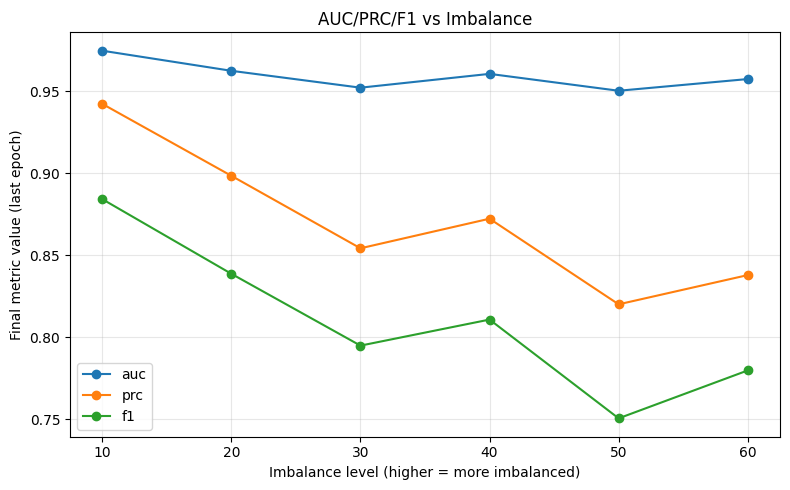

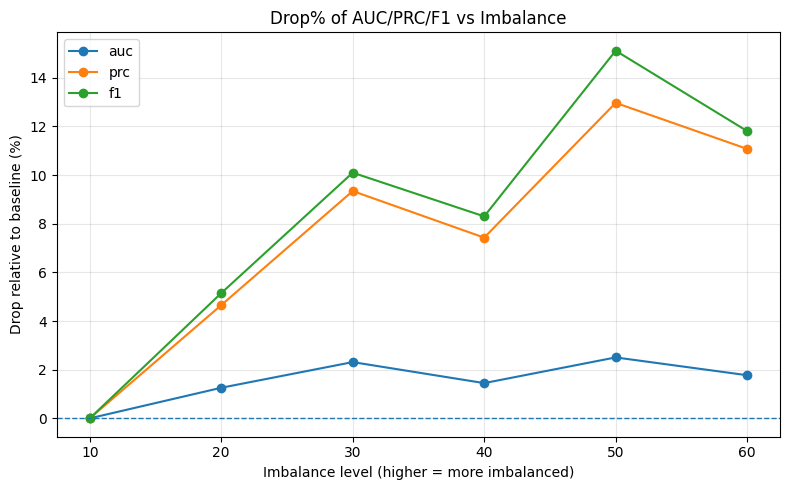

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def summarize_last_metrics(all_results, metrics=None):
    """
    all_results: list of dict, each dict like:
        {
          'train_loss': [...], 'val_loss': [...], 'auc': [...], 'prc': [...], 'f1': [...]
        }
    metrics: list of metric names you want to track. If None, auto-detect common ones.
    return:
        last_vals: dict(metric -> np.array shape [n_runs])
    """
    if metrics is None:
        # 自动从第一组里找指标 key
        metrics = list(all_results[0].keys())

    n = len(all_results)
    last_vals = {m: np.zeros(n, dtype=float) for m in metrics}

    for i, res in enumerate(all_results):
        for m in metrics:
            if m not in res:
                raise KeyError(f"Metric '{m}' not found in run {i}.")
            if len(res[m]) == 0:
                raise ValueError(f"Metric '{m}' list is empty in run {i}.")
            last_vals[m][i] = float(res[m][-1])  # 取最后一个

    return last_vals

def percent_drop(last_vals, baseline_idx=0):
    """
    last_vals: dict(metric -> np.array)
    baseline_idx: which run to treat as baseline (most balanced)
    return:
        drops: dict(metric -> np.array)  # drop% relative to baseline
    """
    drops = {}
    for m, arr in last_vals.items():
        base = arr[baseline_idx]
        # 防止 base=0
        if np.isclose(base, 0):
            drops[m] = np.full_like(arr, np.nan)
        else:
            drops[m] = (base - arr) / base * 100.0
    return drops

def plot_metrics_vs_imbalance(imbalance_levels, last_vals, metrics_to_plot=None, 
                             title="Metrics vs Imbalance"):
    """
    imbalance_levels: list/np.array length n_runs, x-axis
    last_vals: dict(metric -> np.array)
    metrics_to_plot: choose subset to plot; None means plot all
    """
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(last_vals.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = last_vals[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Final metric value (last epoch)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_drop_vs_imbalance(imbalance_levels, drops, metrics_to_plot=None,
                           title="Percent drop vs Imbalance"):
    x = np.array(imbalance_levels, dtype=float)
    if metrics_to_plot is None:
        metrics_to_plot = list(drops.keys())

    plt.figure(figsize=(8,5))
    for m in metrics_to_plot:
        y = drops[m]
        plt.plot(x, y, marker='o', label=m)

    plt.xlabel("Imbalance level (higher = more imbalanced)")
    plt.ylabel("Drop relative to baseline (%)")
    plt.title(title)
    plt.axhline(0, linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def print_summary_table(imbalance_levels, last_vals, drops, metrics=None):
    if metrics is None:
        metrics = list(last_vals.keys())

    print("=== Final metrics (last epoch) and drop% vs baseline ===")
    header = ["imbalance"] + [f"{m}_final" for m in metrics] + [f"{m}_drop%" for m in metrics]
    print("\t".join(header))

    for i, lvl in enumerate(imbalance_levels):
        row = [str(lvl)]
        row += [f"{last_vals[m][i]:.6f}" for m in metrics]
        row += [("nan" if np.isnan(drops[m][i]) else f"{drops[m][i]:.2f}") for m in metrics]
        print("\t".join(row))


# ==========================
# 你需要改的只有这里
# ==========================

# imbalance_levels: 每组结果对应的不平衡程度（你自己定义）
# 例子：正负样本比 1:1, 1:5, 1:10, 1:20 ...
imbalance_levels = [10, 20, 30, 40,50,60]  # <-- 改成你的

# all_results: 多组训练结果，每组一个 dict
# 下面只放了一个示例，你要把你的多组 dict 都塞进 list
all_results = [
    dict_imb10,
dict_imb20,
dict_imb30,
dict_imb40,
dict_imb50,
dict_imb60
]

# 你想画哪些指标（默认是 all_results[0] 里出现的全部 key）
metrics = ['auc', 'prc', 'f1']  # <-- 想加 val_loss/train_loss 也可以放进来

# ==========================
# 跑起来
# ==========================

last_vals = summarize_last_metrics(all_results, metrics=metrics)
drops = percent_drop(last_vals, baseline_idx=0)

print_summary_table(imbalance_levels, last_vals, drops, metrics=metrics)

plot_metrics_vs_imbalance(
    imbalance_levels, last_vals, metrics_to_plot=metrics,
    title="AUC/PRC/F1 vs Imbalance"
)

plot_drop_vs_imbalance(
    imbalance_levels, drops, metrics_to_plot=metrics,
    title="Drop% of AUC/PRC/F1 vs Imbalance"
)
